In [2]:
%pip install numpy
%pip install cv2
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 23.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2

[notice] A new release of pip is available: 23.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 23.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


(-0.5, 639.5, 479.5, -0.5)

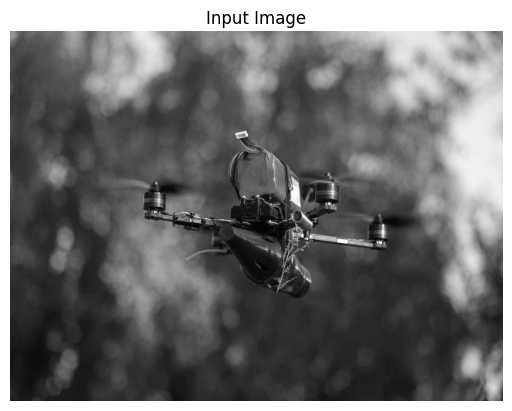

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("images/image.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (640, 480))  # active video region

plt.imshow(img, cmap="gray")
plt.title("Input Image")
plt.axis("off")


In [4]:
video_signal = img.flatten().astype(np.float32)
video_signal /= 255.0  # normalize 0–1


In [5]:
# NTSC constants
FS = 13.5e6
LINE_TIME = 63.556e-6
ACTIVE_TIME = 52.6e-6

SAMPLES_PER_LINE = int(FS * LINE_TIME)
ACTIVE_SAMPLES = int(FS * ACTIVE_TIME)

# Voltage levels
SYNC = -0.4
BLACK = 0.0
WHITE = 0.7


In [6]:
def ntsc_line(active_pixels):
    line = np.ones(SAMPLES_PER_LINE) * BLACK
    
    # Sync pulse
    line[:int(4.7e-6 * FS)] = SYNC
    
    # Active video
    start = int(10.5e-6 * FS)
    line[start:start+ACTIVE_SAMPLES] = active_pixels
    
    return line


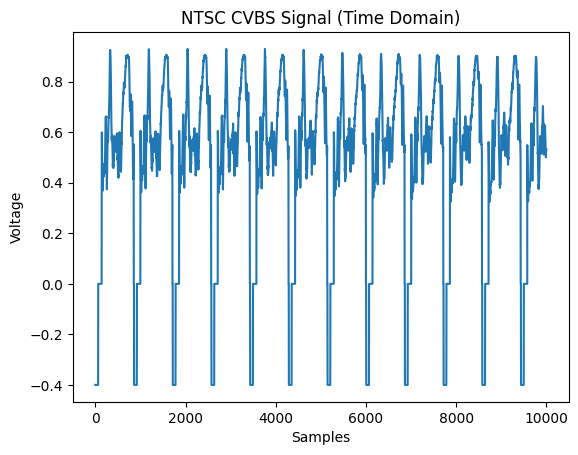

In [7]:
frame = []

pixel_idx = 0
pixels_per_line = img.shape[1]

for _ in range(480):
    pixels = video_signal[pixel_idx:pixel_idx+pixels_per_line]
    pixel_idx += pixels_per_line
    
    pixels = np.interp(
        np.linspace(0, len(pixels), ACTIVE_SAMPLES),
        np.arange(len(pixels)),
        pixels
    )
    
    frame.append(ntsc_line(pixels))

cvbs = np.concatenate(frame)

plt.plot(cvbs[:10000])
plt.title("NTSC CVBS Signal (Time Domain)")
plt.xlabel("Samples")
plt.ylabel("Voltage")
plt.show()



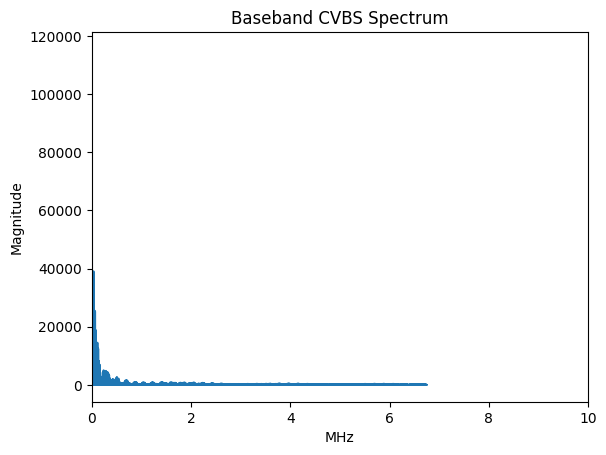

In [8]:
fft = np.fft.fft(cvbs)
freqs = np.fft.fftfreq(len(fft), 1/FS)

plt.plot(freqs/1e6, np.abs(fft))
plt.xlim(0, 10)
plt.title("Baseband CVBS Spectrum")
plt.xlabel("MHz")
plt.ylabel("Magnitude")
plt.show()


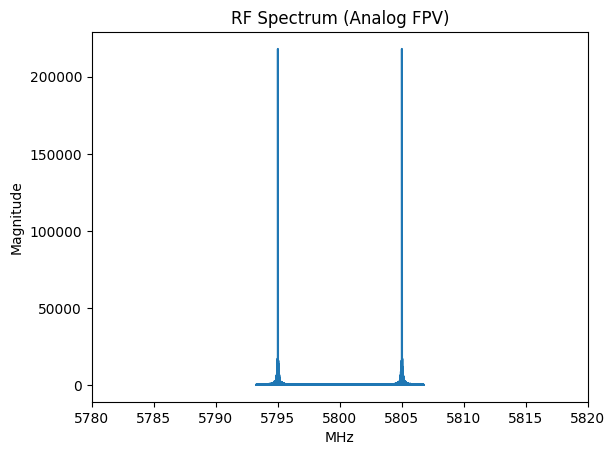

In [9]:
FC = 5.8e9      # carrier (example)
t = np.arange(len(cvbs)) / FS

rf = (1 + cvbs) * np.cos(2 * np.pi * FC * t)

rf_fft = np.fft.fft(rf)
rf_freqs = np.fft.fftfreq(len(rf_fft), 1/FS)

plt.plot((rf_freqs + FC)/1e6, np.abs(rf_fft))
plt.xlim((FC-20e6)/1e6, (FC+20e6)/1e6)
plt.title("RF Spectrum (Analog FPV)")
plt.xlabel("MHz")
plt.ylabel("Magnitude")
plt.show()


In [10]:
from scipy.signal import stft

NFFT = 4096
HOP = NFFT // 4

f, t_spec, S = stft(
    rf,
    fs=FS,
    nperseg=NFFT,
    noverlap=NFFT - HOP,
    window="hann",
    return_onesided=False
)


In [11]:
S = np.fft.fftshift(S, axes=0)
f = np.fft.fftshift(f)


In [12]:
S_db = 20 * np.log10(np.abs(S) + 1e-12)



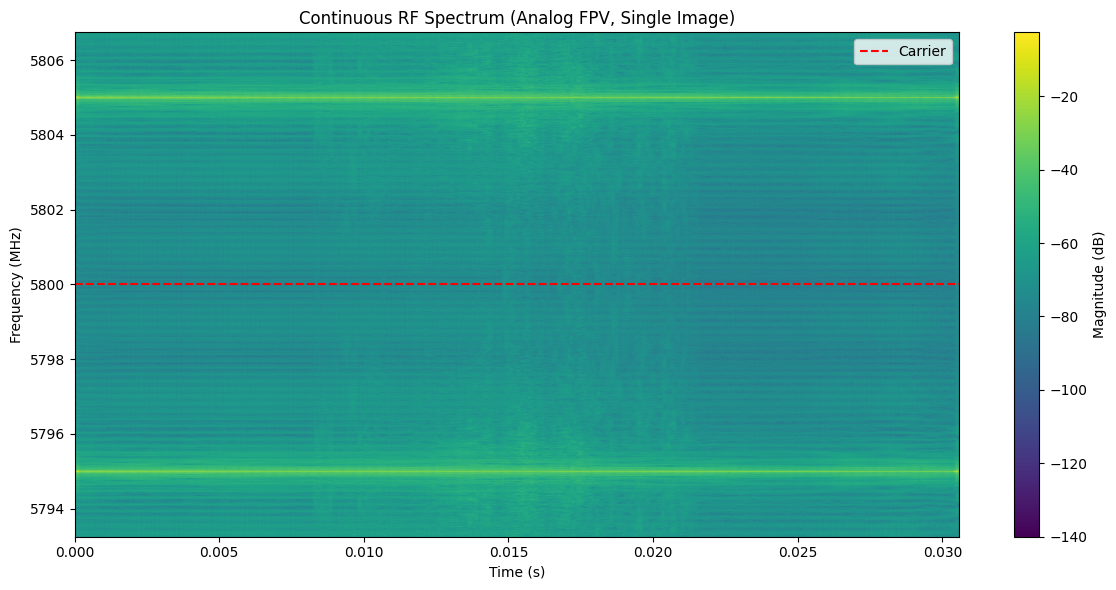

In [13]:
plt.figure(figsize=(12, 6))

plt.imshow(
    S_db,
    aspect="auto",
    origin="lower",
    extent=[
        t_spec[0],
        t_spec[-1],
        (FC + f[0]) / 1e6,
        (FC + f[-1]) / 1e6,
    ],
    cmap="viridis"
)

plt.colorbar(label="Magnitude (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("Continuous RF Spectrum (Analog FPV, Single Image)")

# Center frequency line
plt.axhline(FC / 1e6, color="red", linestyle="--", linewidth=1.5, label="Carrier")

plt.legend()
plt.tight_layout()
plt.show()
